# ERA5 blocking diagnostics: a first TM1990 analysis

This notebook is the first scientific step after the raw-download EDA. It
does **not** use EERIE or make a causal claim about ocean coupling. It applies
one transparent, configurable Tibaldi–Molteni (TM1990) blocking diagnostic to
the ERA5 500 hPa geopotential-height fields already downloaded for January
2023 and November–December 2024.

The workflow is deliberately staged:

1. verify that the blocking-specific ERA5 cache has the northern latitude
   margin required by the 40°N / 60°N / 80°N height bands;
2. inspect the two meridional height gradients that define a candidate;
3. apply the gradient threshold and a contiguous-longitude-sector filter;
4. summarise persistence in the 6-hourly sequence.

These windows are smoke tests, not a blocking climatology. A later historical
analysis must use many complete winters and compare the resulting frequency
with published diagnostics before EERIE projections are interpreted.


In [1]:
# Setup: load the blocking-domain ERA5 caches and plotting dependencies.
from datetime import datetime
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from IPython.display import display
from matplotlib.ticker import FixedLocator

from eurogrid.data.era5 import load_era5
from eurogrid.diagnostics.blocking import detect_tm1990, persistence_summary

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
with open(ROOT / "config/settings.yaml") as handle:
    cfg = yaml.safe_load(handle)

blocking_domain = cfg["blocking"]["domain"]
blocking_cfg = cfg["blocking"]
windows = {
    "2023-01": ("2023-01-01T00:00:00", "2023-02-01T00:00:00"),
    "2024-11..12": ("2024-11-01T00:00:00", "2025-01-01T00:00:00"),
}
PC = ccrs.PlateCarree()

In [2]:
# Load the expanded-latitude ERA5 caches and verify the fields used below.
era5_blocking = {}
for label, (start, end) in windows.items():
    era5_blocking[label] = load_era5(
        datetime.fromisoformat(start),
        datetime.fromisoformat(end),
        **blocking_domain,
        cache_dir=ROOT / cfg["era5"]["cache_dir"],
        z500_stride_hours=cfg["era5"]["z500_stride_hours"],
    )

inventory = pl.DataFrame(
    [
        {
            "window": label,
            "z500_shape": list(ds.z500.shape),
            "lat_min": float(ds.lat.min()),
            "lat_max": float(ds.lat.max()),
            "lon_min": float(ds.lon.min()),
            "lon_max": float(ds.lon.max()),
            "timesteps": ds.sizes["time_z500"],
            "cadence_hours": float((ds.time_z500.diff("time_z500") / np.timedelta64(1, "h")).median()),
        }
        for label, ds in era5_blocking.items()
    ]
)
display(inventory)

window,z500_shape,lat_min,lat_max,lon_min,lon_max,timesteps,cadence_hours
str,list[i64],f64,f64,f64,f64,i64,f64
"""2023-01""","[124, 221, 321]",30.0,85.0,-40.0,40.0,124,6.0
"""2024-11..12""","[244, 221, 321]",30.0,85.0,-40.0,40.0,244,6.0


## Why the blocking cache is larger than the wind-resource cache

The earlier EDA cache covered 30–75°N, which is sufficient for a European
wind map but not for the standard TM1990 north band. TM1990 compares
geopotential height near 40°N, 60°N, and 80°N, with a small latitude shift
(`Δ = −4°, 0°, +4°` here). The blocking cache therefore reaches 85°N.

For each longitude and time, the diagnostic computes

\[
GHGS = rac{Z(60^\circ+\Delta)-Z(40^\circ+\Delta)}{20^\circ}
\]

and

\[
GHGN = rac{Z(80^\circ+\Delta)-Z(60^\circ+\Delta)}{20^\circ}.
\]

A candidate has `GHGS > 0` and `GHGN < -10 m per degree latitude` for at
least one shift. In plain language: height rises from the south into the
mid-latitude ridge, then falls unusually sharply toward the north. That
reversed north–south pattern is a signature of a blocking-like ridge, not a
proof that blocking caused any particular surface event.


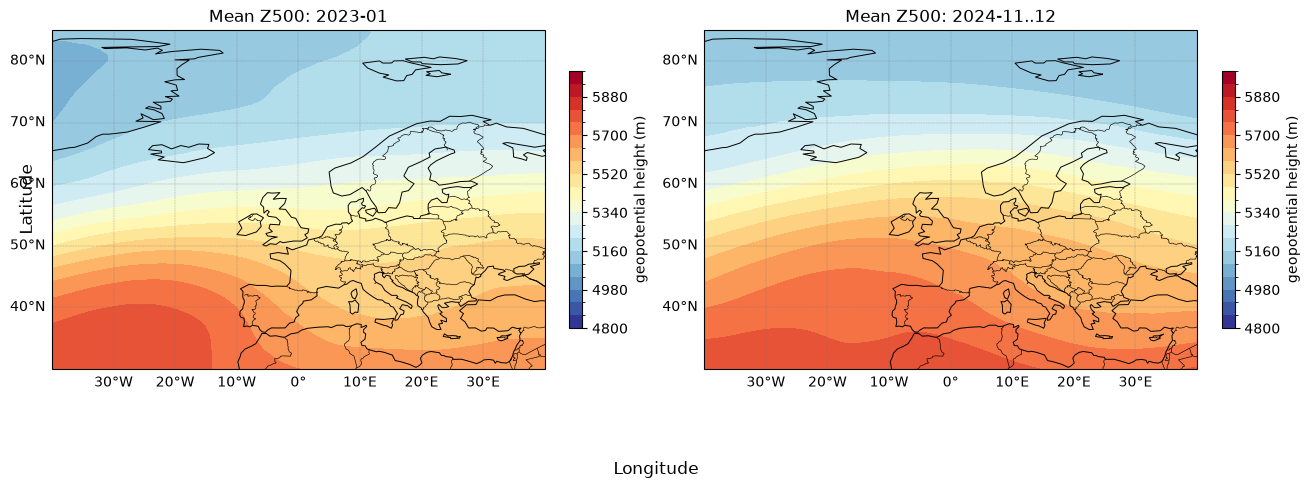

In [3]:
# Plot the short-window mean Z500 fields to confirm the expanded circulation domain.
def map_ax(ax, title):
    ax.set_extent(
        [
            blocking_domain["lon_min"],
            blocking_domain["lon_max"],
            blocking_domain["lat_min"],
            blocking_domain["lat_max"],
        ],
        crs=PC,
    )
    ax.coastlines(linewidth=0.7)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.45)
    gl = ax.gridlines(
        crs=PC,
        draw_labels=True,
        linewidth=0.35,
        color="0.45",
        alpha=0.6,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = FixedLocator(np.arange(-40, 41, 10))
    gl.ylocator = FixedLocator(np.arange(30, 86, 10))
    ax.set_title(title)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.8),
    subplot_kw={"projection": PC},
    constrained_layout=True,
)
for ax, (label, ds) in zip(axes, era5_blocking.items(), strict=True):
    ds.z500.mean("time_z500").plot.contourf(
        ax=ax,
        transform=PC,
        levels=np.arange(4800, 6001, 60),
        cmap="RdYlBu_r",
        add_colorbar=True,
        cbar_kwargs={"label": "geopotential height (m)", "shrink": 0.45},
    )
    map_ax(ax, f"Mean Z500: {label}")
fig.supxlabel("Longitude", y=0.02)
fig.supylabel("Latitude", x=0.01)
plt.show()

*Figure — short-window mean 500 hPa geopotential height in the expanded
blocking domain. Source: ERA5 via ARCO, cached locally; analysis: mean of
6-hourly `z500` fields. The maps are circulation-context checks, not blocking
events. Political borders and longitude/latitude grid labels verify the
domain used by the diagnostic. The short windows are too brief for
climatological conclusions.*


In [4]:
# Compute TM1990 gradients and the candidate/sector-qualified masks for each window.
tm_results = {}
persistence_results = {}
for label, ds in era5_blocking.items():
    tm_results[label] = detect_tm1990(
        ds.z500,
        phi0_deg=blocking_cfg["phi0_deg"],
        arm_deg=blocking_cfg["arm_deg"],
        scan_offsets_deg=tuple(blocking_cfg["scan_offsets_deg"]),
        ghgn_threshold_m_per_deg=blocking_cfg["ghgn_threshold_m_per_deg"],
        min_sector_width_deg=blocking_cfg["min_sector_width_deg"],
    )
    persistence_results[label] = persistence_summary(
        tm_results[label].blocking,
        timestep_hours=cfg["era5"]["z500_stride_hours"],
        min_persistence_days=blocking_cfg["min_persistence_days"],
    )

summary = pl.DataFrame(
    [
        {
            "window": label,
            "candidate_fraction": float(result.candidate.mean()),
            "sector_qualified_fraction": float(result.blocking.mean()),
            "persistent_fraction": float(persistence_results[label].persistent_blocking.mean()),
            "maximum_blocked_longitudes": int(persistence_results[label].blocking_longitude_count.max()),
        }
        for label, result in tm_results.items()
    ]
)
display(summary)

window,candidate_fraction,sector_qualified_fraction,persistent_fraction,maximum_blocked_longitudes
str,f64,f64,f64,i64
"""2023-01""",0.138881,0.133454,0.274194,208
"""2024-11..12""",0.162032,0.119733,0.081967,231


**Table — first TM1990 diagnostic summary.** `candidate_fraction` is the
fraction of all time–longitude cells satisfying the two gradient inequalities.
`sector_qualified_fraction` is smaller or equal because it additionally
requires a contiguous longitude sector at least 20° wide. `persistent_fraction`
is the fraction of 6-hourly times belonging to a domain-wide run lasting at
least five days. `maximum_blocked_longitudes` is a count of grid longitudes,
not a physical area or number of blocking events. These values describe the
two downloaded windows only; they are not an estimate of the climatological
blocking frequency.


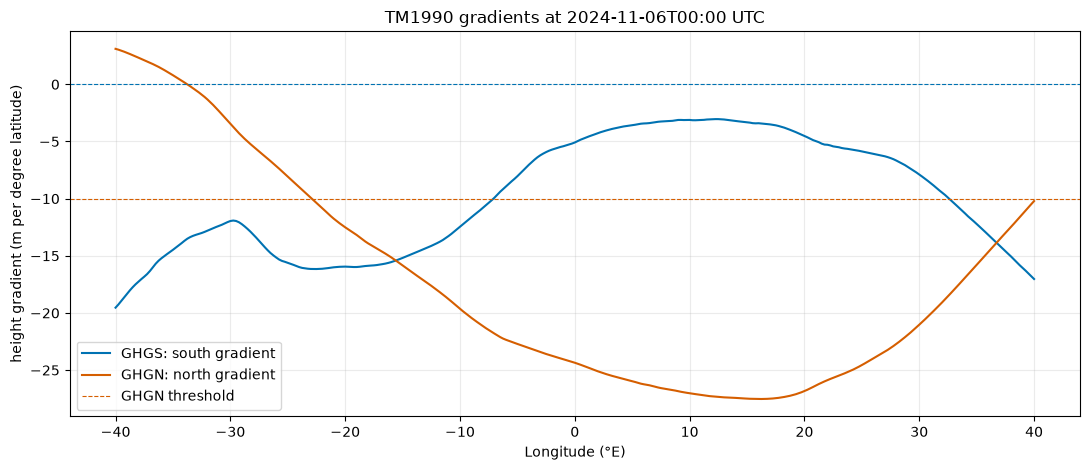

In [5]:
# Plot the two meridional gradients and thresholds for one representative timestep.
label = "2024-11..12"
result = tm_results[label]
time_index = min(20, result.sizes["time_z500"] - 1)
gradient_center = result.ghgs.isel(scan_latitude=1, time_z500=time_index)
gradient_north = result.ghgn.isel(scan_latitude=1, time_z500=time_index)

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(result.lon, gradient_center, label="GHGS: south gradient", color="#0072B2")
ax.plot(result.lon, gradient_north, label="GHGN: north gradient", color="#D55E00")
ax.axhline(0, color="#0072B2", linestyle="--", linewidth=0.8)
ax.axhline(
    blocking_cfg["ghgn_threshold_m_per_deg"],
    color="#D55E00",
    linestyle="--",
    linewidth=0.8,
    label="GHGN threshold",
)
ax.set(
    xlabel="Longitude (°E)",
    ylabel="height gradient (m per degree latitude)",
    title=f"TM1990 gradients at {str(result.time_z500[time_index].values)[:16]} UTC",
)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

*Figure — one 6-hourly example of the two quantities used by TM1990. Source:
ERA5 `z500`, local expanded-domain cache; analysis: 20° meridional gradients
at the central 60°N scan. A candidate longitude requires the blue GHGS curve
above zero and the orange GHGN curve below −10 m per degree latitude for at
least one latitude shift. This is an intermediate diagnostic: it shows why a
longitude is or is not a candidate before sector width and persistence are
applied.*


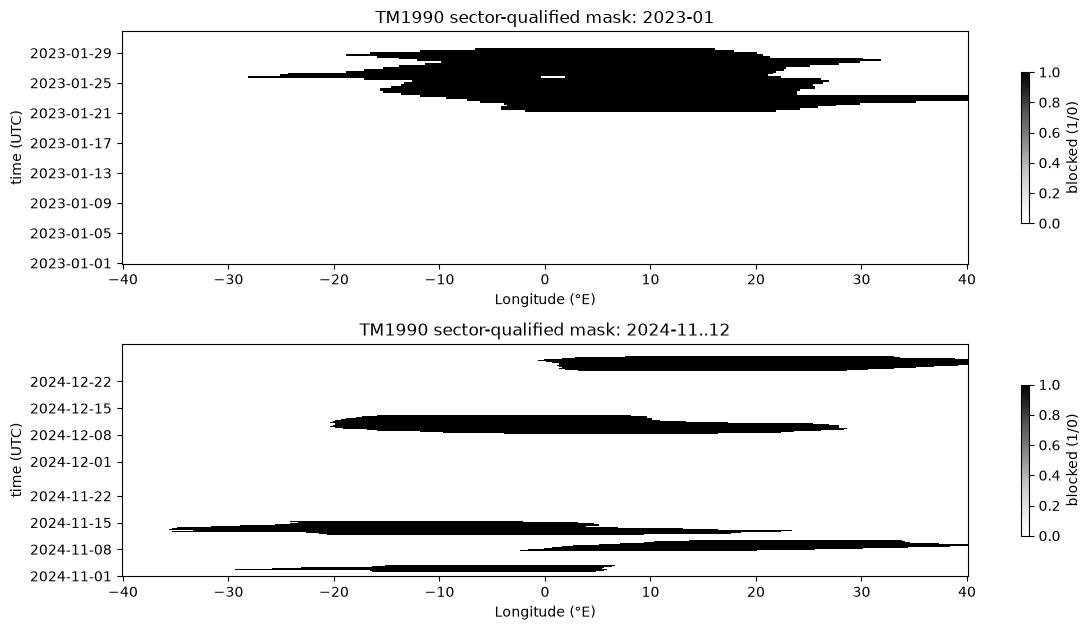

In [6]:
# Plot the sector-qualified blocking mask as a time–longitude Hovmöller diagram.
fig, axes = plt.subplots(
    len(tm_results),
    1,
    figsize=(12, 3.2 * len(tm_results)),
    sharex=False,
    squeeze=False,
)
for ax, (label, result) in zip(axes[:, 0], tm_results.items(), strict=True):
    result.blocking.astype(int).plot(
        ax=ax,
        cmap="Greys",
        vmin=0,
        vmax=1,
        add_colorbar=True,
        cbar_kwargs={"label": "blocked (1/0)", "shrink": 0.65},
    )
    ax.set(
        title=f"TM1990 sector-qualified mask: {label}",
        xlabel="Longitude (°E)",
        ylabel="time (UTC)",
    )
fig.tight_layout()
plt.show()

*Figure — time–longitude view of the sector-qualified TM1990 mask. Source:
ERA5 `z500`, local cache; analysis: gradient thresholds plus the 20° contiguous
sector rule. Horizontal runs show the longitude extent of a candidate at each
6-hourly time. Persistence is assessed from consecutive times, but this plot
does not yet track separate named events or merge nearby sectors.*


## Interpretation and limits of this first diagnostic

- The implementation is a transparent TM1990-style detector, not a causal
  model and not yet the final event-tracking method.
- The 40°N / 60°N / 80°N bands and the −10 m per degree threshold follow the
  standard formulation; the ±4° latitude shifts, 20° sector filter, and
  five-day persistence rule are explicit project settings.
- The two cached windows are useful for verifying the pipeline and for seeing
  intermediate fields. They cannot establish a climatological blocking
  frequency or validate the model.
- The next scientific refinement is to run this same function on many complete
  ERA5 winters, compare frequency by longitude with published blocking
  climatologies, and only then use it as the benchmark for EERIE.
